## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_5_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

# Datos del estudiante


*   Lukas Piedrahita Serna

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

In [ ]:
# Cantidad de no nulos por categoría y total de entradas
df.info()
# Cantidad de nulos por categoría
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre        6 non-null      object 
 1   Edad          5 non-null      float64
 2   Ciudad        6 non-null      object 
 3   Ingreso       5 non-null      float64
 4   FechaIngreso  5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes


,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


De este análisis se identificó que se cuentan con 7 registros y en cada columna hay entre 1 y 2 valores nulos. En la variable "Edad" también se evidencia un valor negativo.

Ya que el dataset es pequeño y visiblemente es fácil identificar que no hay entradas repetidas ni problemas tipográficos o de formatos. Tampoco se realiza una identificación de outliers.

Para finalizar se realiza la imputación de datos faltantes en el dataset.

In [ ]:
# Imputación de datos
df_imputed = df.copy()

#Categorizar como "Desconocido" valores nulos en las variables "Nombre" y "Ciudad"
df_imputed['Nombre'] = df_imputed['Nombre'].fillna('Desconocido')
df_imputed['Ciudad'] = df_imputed['Ciudad'].fillna('Desconocido')

#Convertir valores negativos en edad a NaN
df_imputed['Edad'] = df_imputed['Edad'].apply(lambda x: np.nan if x < 0 else x)

# Imputación de valores numéricos a través de la mediana
df_imputed['Edad'] = df_imputed['Edad'].fillna(df_imputed['Edad'].median())
df_imputed['Ingreso'] = df_imputed['Ingreso'].fillna(df_imputed['Ingreso'].median())

# Imputación de fechas
df_imputed['FechaIngreso'] = df_imputed['FechaIngreso'].replace({pd.NaT: np.nan})
df_imputed['FechaIngreso'] = df_imputed['FechaIngreso'].fillna(pd.to_datetime('1900-01-01'))

In [ ]:
print("Valores faltantes luego de la limpieza e imputación:")
print(df_imputed.isnull().sum())

print("\nDataFrame limpio:")
print(df_imputed)

Valores faltantes luego de la limpieza e imputación:
Nombre          0
Edad            0
Ciudad          0
Ingreso         0
FechaIngreso    0
dtype: int64

DataFrame limpio:
        Nombre  Edad       Ciudad  Ingreso         FechaIngreso
0          Ana  25.0       Bogotá   3500.0           2023-01-01
1         Luis  27.0     Medellín   4800.0           2023-01-05
2        Pedro  35.0  Desconocido   4800.0  1900-01-01 00:00:00
3  Desconocido  29.0     Medellín   5200.0           2023-01-10
4        Marta  27.0         Cali   5100.0           2023-01-12
5         Luis  25.0       Bogotá   4800.0  1900-01-01 00:00:00
6        Sofía  27.0         Cali   4700.0           2023-01-15


## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:

In [ ]:
import pandas as pd

df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

In [ ]:
#Registros originales
total_registros = len(df)
print("Total de registros originales:", total_registros)

#Duplicados exactos
duplicados_exactos = df[df.duplicated()]
print("\nDuplicados exactos:\n", duplicados_exactos)
print("Cantidad de duplicados exactos:", duplicados_exactos.shape[0])

#Duplicados por columnas (Columnas seleccionadas: "ID" y "Nombre")
duplicados_subset = df[df.duplicated(subset=['ID', 'Nombre'], keep=False)]
print("\nDuplicados por ID y Nombre:\n", duplicados_subset)
print("Cantidad de duplicados por ID y Nombre:", duplicados_subset.shape[0])

#Registros por eliminar y cantidad de registros después de eliminación
print("\nRegistros que se deben eliminar:", duplicados_exactos.shape[0])
df_limpio = df.drop_duplicates()
print("Registros después de eliminar duplicados:", len(df_limpio))

print("\nDataFrame limpio:")
print(df_limpio)

Total de registros originales: 7

Duplicados exactos:
     ID  Nombre  Edad Ciudad FechaRegistro
2  102    Luis    30   Cali    2023-01-05
5  104  Carlos    40   Cali    2023-01-15
Cantidad de duplicados exactos: 2

Duplicados por ID y Nombre:
     ID  Nombre  Edad Ciudad FechaRegistro
1  102    Luis    30   Cali    2023-01-05
2  102    Luis    30   Cali    2023-01-05
4  104  Carlos    40   Cali    2023-01-15
5  104  Carlos    40   Cali    2023-01-15
6  104  Carlos    41   Cali    2023-01-16
Cantidad de duplicados por ID y Nombre: 5

Registros que se deben eliminar: 2
Registros después de eliminar duplicados: 5

DataFrame limpio:
    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16


## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:

In [ ]:
import pandas as pd

df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

In [ ]:
import unicodedata
df_estandarizado = df.copy()

def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text

df_estandarizado['Ciudad'] = df_estandarizado['Ciudad'].apply(remove_accents).str.lower()

print("\nDataFrame estandarizado:")
print(df_estandarizado)


DataFrame estandarizado:
      Ciudad
0     bogota
1     bogota
2     bogota
3     bogota
4     bogata
5     bogota
6     bogota
7       cali
8       cali
9   medellin
10  medellin


## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

**1 → MCAR:** Ya que se menciona que los datos faltantes no dependen de ninguna variable, ni obsevada ni no observada.

**2 → MAR:** Ya que los valores faltantes dependen de una variable observada diferente a la que contiene el valor.

**3 → MAR:** Ya que los valores faltantes dependen de una variable observada diferente a la que contiene el valor.

**4 → MAR:** Ya que los valores faltantes dependen de una variable observada diferente a la que contiene el valor.

**5 → MNAR:** Ya que los valores faltantes, no observados, dependen de estos mismos.

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

**Solución 2.**

In [ ]:
df.info()
print("\nValores nulos por columna:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                30 non-null     int64  
 1   Promedio            26 non-null     float64
 2   Horas_estudio       26 non-null     float64
 3   Ingreso_familiar    27 non-null     float64
 4   Semestres_cursados  30 non-null     int64  
dtypes: float64(3), int64(2)
memory usage: 1.3 KB

Valores nulos por columna:


,0
Edad,0
Promedio,4
Horas_estudio,4
Ingreso_familiar,3
Semestres_cursados,0


Las variables con mayor proporción de datos faltantes son "Promedio" y "Horas_estudio", y aparentan ser aleatorios.

**Solución 3.**

In [ ]:
# Imputación con Knn
df_knn = df.copy()

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors = 3)
df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_knn), columns = df_knn.columns)

print("\nDataFrame con imputación KNN:")
print(df_knn_imputed)


DataFrame con imputación KNN:
    Edad  Promedio  Horas_estudio  Ingreso_familiar  Semestres_cursados
0   56.0  2.700000      35.000000      2.909818e+06                 7.0
1   46.0  2.270000      21.333333      3.031785e+06                 7.0
2   32.0  3.473333      30.000000      5.283302e+06                 9.0
3   25.0  3.150000      14.000000      2.955269e+06                 3.0
4   38.0  4.950000       7.000000      3.525928e+06                 7.0
5   56.0  3.473333      13.000000      4.653339e+06                 1.0
6   36.0  4.580000      22.000000      3.609593e+06                 4.0
7   40.0  4.040000      21.333333      1.879111e+06                 4.0
8   28.0  3.473333      20.000000      1.796107e+06                 5.0
9   28.0  2.040000      15.000000      4.321441e+06                 7.0
10  41.0  4.830000      21.333333      7.930144e+06                 7.0
11  53.0  3.690000      23.000000      5.345583e+06                 4.0
12  57.0  3.160000      25.000000

In [ ]:
# Imputación con regresión
df_regresion = df.copy()

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42)
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_regresion), columns = df_regresion.columns)

print("\nDataFrame con imputación regresión:")
print(df_reg_imputed)


DataFrame con imputación regresión:
    Edad  Promedio  Horas_estudio  Ingreso_familiar  Semestres_cursados
0   56.0  2.700000      35.000000      2.909818e+06                 7.0
1   46.0  2.270000      20.673514      3.031785e+06                 7.0
2   32.0  3.415054      30.000000      5.283302e+06                 9.0
3   25.0  3.150000      14.000000      4.339501e+06                 3.0
4   38.0  4.950000       7.000000      3.525928e+06                 7.0
5   56.0  3.390536      13.000000      4.653339e+06                 1.0
6   36.0  4.580000      22.000000      4.339501e+06                 4.0
7   40.0  4.040000      22.445729      1.879111e+06                 4.0
8   28.0  3.271704      20.000000      1.796107e+06                 5.0
9   28.0  2.040000      15.000000      4.321441e+06                 7.0
10  41.0  4.830000      13.142201      7.930144e+06                 7.0
11  53.0  3.690000      23.000000      5.345583e+06                 4.0
12  57.0  3.160000      25.

**Solución 4.**

In [ ]:
df.describe()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
count,30.000000,26.000000,26.000000,2.700000e+01,30.000000
mean,39.866667,3.376923,18.769231,4.339501e+06,5.533333
std,11.512312,0.900208,10.366514,1.752491e+06,2.596195
min,19.000000,2.040000,0.000000,1.291234e+06,1.000000
25%,32.250000,2.637500,10.750000,2.915754e+06,4.000000
50%,40.500000,3.235000,21.000000,4.402279e+06,6.000000
75%,46.750000,4.047500,24.750000,5.314442e+06,7.000000
max,59.000000,4.950000,35.000000,7.930144e+06,9.000000


In [ ]:
df_knn_imputed.describe()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
count,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,39.866667,3.389778,19.111111,4.217002e+06,5.533333
std,11.512312,0.836486,9.665808,1.704828e+06,2.596195
min,19.000000,2.040000,0.000000,1.291234e+06,1.000000
25%,32.250000,2.692500,13.250000,2.912786e+06,4.000000
50%,40.500000,3.411667,21.333333,4.129085e+06,6.000000
75%,46.750000,3.987500,24.000000,5.264558e+06,7.000000
max,59.000000,4.950000,35.000000,7.930144e+06,9.000000


In [ ]:
df_reg_imputed.describe()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
count,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,39.866667,3.376690,18.662849,4.339501e+06,5.533333
std,11.512312,0.836129,9.729044,1.659371e+06,2.596195
min,19.000000,2.040000,0.000000,1.291234e+06,1.000000
25%,32.250000,2.692500,13.035550,2.949214e+06,4.000000
50%,40.500000,3.315000,20.336757,4.339501e+06,6.000000
75%,46.750000,3.987500,24.000000,5.264558e+06,7.000000
max,59.000000,4.950000,35.000000,7.930144e+06,9.000000


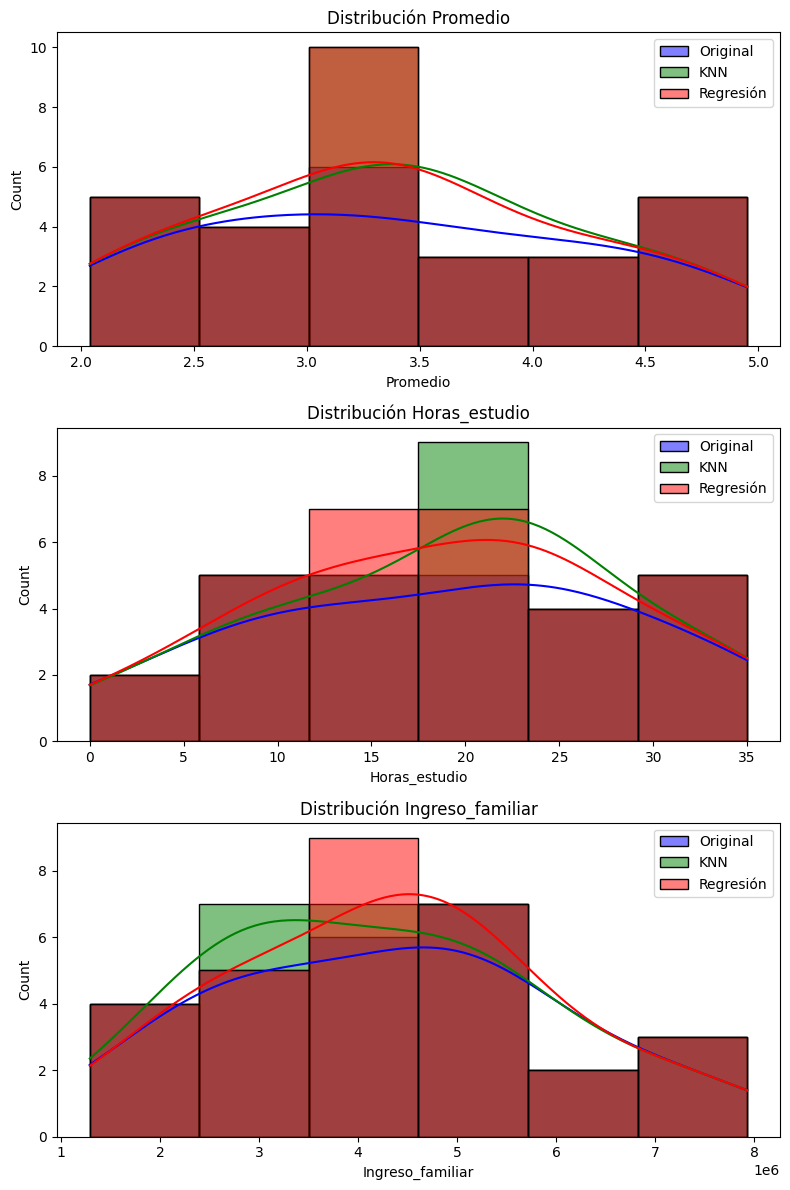

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

sns.histplot(df['Promedio'], kde=True, ax=axes[0], color='blue', label='Original')
sns.histplot(df_knn_imputed['Promedio'], kde=True, ax=axes[0], color='green', label='KNN')
sns.histplot(df_reg_imputed['Promedio'], kde=True, ax=axes[0], color='red', label='Regresión')
axes[0].legend()
axes[0].set_title('Distribución Promedio')

sns.histplot(df['Horas_estudio'], kde=True, ax=axes[1], color='blue', label='Original')
sns.histplot(df_knn_imputed['Horas_estudio'], kde=True, ax=axes[1], color='green', label='KNN')
sns.histplot(df_reg_imputed['Horas_estudio'], kde=True, ax=axes[1], color='red', label='Regresión')
axes[1].legend()
axes[1].set_title('Distribución Horas_estudio')

sns.histplot(df['Ingreso_familiar'], kde=True, ax=axes[2], color='blue', label='Original')
sns.histplot(df_knn_imputed['Ingreso_familiar'], kde=True, ax=axes[2], color='green', label='KNN')
sns.histplot(df_reg_imputed['Ingreso_familiar'], kde=True, ax=axes[2], color='red', label='Regresión')
axes[2].legend()
axes[2].set_title('Distribución Ingreso_familiar')

plt.tight_layout()
plt.show()

Los valores derivados de un análisis numérico (std, mean, ...) cambian ligeramente pero con cada técnica la naturaleza de los datos se mantiene de forma lo suficientemente similar.

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?

**Solución 2.**

In [ ]:
df[df.isnull().any(axis=1)]

,Fecha,Ventas,Inventario,Clientes
1,2023-01-02,480.29,16.0,NaN
2,2023-01-03,392.80,30.0,NaN
3,2023-01-04,NaN,82.0,44.0
4,2023-01-05,NaN,48.0,34.0
5,2023-01-06,NaN,27.0,10.0
7,2023-01-08,446.47,NaN,14.0
8,2023-01-09,340.45,NaN,31.0
12,2023-01-13,NaN,62.0,14.0
13,2023-01-14,NaN,11.0,23.0
18,2023-01-19,272.78,17.0,NaN


La categorias "Ventas", "Inventario" y "Clientes" tienen datos faltantes consecutivos.

Este patrón es relevante en series temporales porque permite analizar la continuidad en los datos y puede ser una forma de analizar las ocurrencias, tomando como base lo que paso antes o después en la serie.

Para este tipo de imputación, que se basa en los valores anteriores o siguientes al valor a imputar, el orden de los datos tiene gran relevncia.

**Solución 3.**

In [ ]:
# Imputación LOCF
df_locf = df.copy()

df_locf = df_locf.fillna(method='ffill')
df_locf

/tmp/ipykernel_4436/3146654222.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_locf = df_locf.fillna(method='ffill')


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,29.0
2,2023-01-03,392.80,30.0,29.0
3,2023-01-04,392.80,82.0,44.0
4,2023-01-05,392.80,48.0,34.0
5,2023-01-06,392.80,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,13.0,14.0
8,2023-01-09,340.45,13.0,31.0
9,2023-01-10,383.23,23.0,48.0


In [ ]:
# Imputación NOCB
df_nocb = df.copy()

df_nocb = df_nocb.fillna(method='bfill')
df_nocb

/tmp/ipykernel_4436/3140978380.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nocb = df_nocb.fillna(method='bfill')


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,44.0
2,2023-01-03,392.80,30.0,44.0
3,2023-01-04,123.23,82.0,44.0
4,2023-01-05,123.23,48.0,34.0
5,2023-01-06,123.23,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,23.0,14.0
8,2023-01-09,340.45,23.0,31.0
9,2023-01-10,383.23,23.0,48.0


**Solución 4.**

LOCF es más apropiado ya que al ser una serie temporal de ventas, donde el interés principal es ver como la linea temporal avanza, es más acertado rellenar los datos faltantes con datos anteriores.